Importing Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [2]:
#load dataset
gold_data = pd.read_csv(r'D:\Projects\ML_projects\Gold-PricePrediction\gld_price_data.csv')

In [3]:
#print first 5 rows in the dataset
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
#print last 5 rows
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [13]:
#number of rows and columns
gold_data.shape

(2290, 6)

In [14]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [17]:
#checking the number of missing values
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [19]:
#get statistical data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
    1. Positive correlation
    2. Negative correlation

In [6]:
correlation = gold_data.corr(numeric_only = True)

<Axes: >

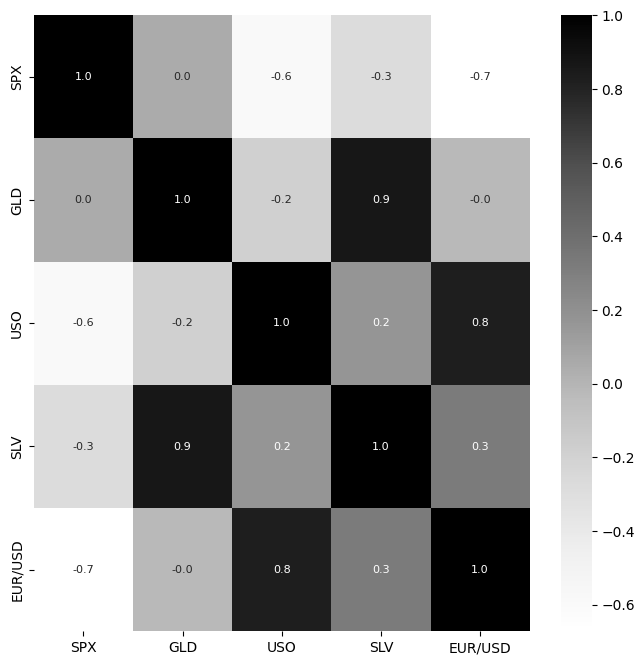

In [ ]:
plt.figure(figsize = (8, 8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Grays')

In [9]:
#correlation values
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


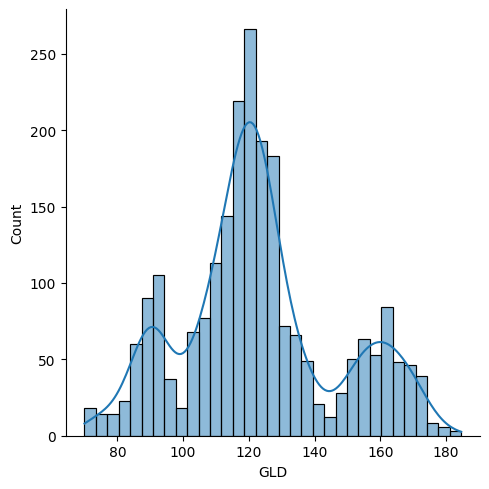

In [12]:
#distributon of GLD
sns.displot(gold_data['GLD'], kde=True)

Splitting the Features and Target

In [17]:
X = gold_data.drop(['Date', 'GLD'], axis=1)
Y = gold_data['GLD']

In [18]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [19]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training and Test data

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

Model Training: Random Forest Regressor

In [21]:
X_test.shape

(458, 4)

In [22]:

regressor = RandomForestRegressor(n_estimators=100)

In [23]:
#training the model
regressor.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model Evaluation

In [24]:
#prediction on Test Data
test_data_prediction = regressor.predict(X_test)

In [25]:
print(test_data_prediction)

[168.6445995   81.90009983 115.85750015 127.56270079 120.72820146
 154.64079771 150.29819803 125.98250014 117.46069862 126.02050072
 116.59030098 171.97190127 141.03889913 167.77799862 115.2159001
 117.51420062 137.97060289 169.88040105 159.71440383 160.20070028
 155.21149997 125.30360009 176.55409984 156.69490435 125.25510036
  93.79939987  77.6421002  120.97419968 119.14769954 167.5022994
  88.27070019 125.10249987  91.5224006  117.80640026 121.16219902
 136.16530017 115.54320108 114.98960043 148.15080005 107.32280108
 104.49750292  87.27329788 126.44710096 118.08239952 152.77099824
 119.58629985 108.31839985 108.24319827  93.17480033 127.33049706
  74.83180028 113.71459892 121.13369982 111.38969908 118.81159901
 120.57219942 158.7776005  166.65840118 147.08349698  85.77269869
  94.44700041  86.78919913  90.76790049 119.03500076 126.45860042
 127.59060011 169.27389992 122.3125995  117.35729857  98.71550047
 168.72380058 143.12249792 131.65000205 121.07270212 121.3801995
 119.63050029

In [28]:
#R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print(error_score)

0.9894970013130956


Compare the Actual and Predicted Valued in a Plot

In [29]:
Y_test = list(Y_test)

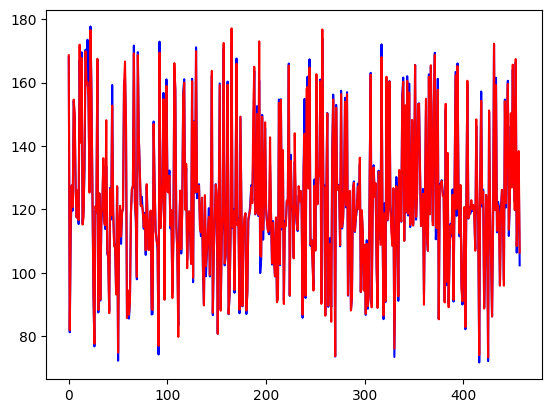

In [32]:
plt.plot(Y_test, color='blue', label='Actual Values')
plt.plot(test_data_prediction, color='red', label='Predicted Value')
